In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\Hafsa\Downloads\Dataset\diamonds.csv") 
df.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


In [3]:
df=df.drop(columns= ["fancy_color_secondary_color", "fancy_color_overtone", "culet_condition", "eye_clean"])
df.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,culet_size,...,meas_length,meas_width,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,N,...,2.85,2.87,1.79,M,M,unknown,NaN,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,N,...,2.84,2.89,1.78,STK,STK,unknown,NaN,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,2.88,2.90,1.77,TN,M,unknown,NaN,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,2.86,2.88,1.78,M,STK,unknown,NaN,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,N,...,2.79,2.83,1.82,STK,STK,unknown,NaN,unknown,unknown,200


In [4]:
for col in ['fancy_color_dominant_color', 'fancy_color_intensity', 'fluor_color', 'fluor_intensity']:
    df[col] = df[col].fillna('unknown')

print(df[['fancy_color_dominant_color', 'fancy_color_intensity',
          'fluor_color', 'fluor_intensity']].isnull().sum())
print(df['fluor_intensity'].value_counts())

fancy_color_dominant_color    0
fancy_color_intensity         0
fluor_color                   0
fluor_intensity               0
dtype: int64
fluor_intensity
unknown        143619
Faint           38302
Medium          20705
Strong          13243
Very Slight      2729
Very Strong      1093
Slight             12
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder

cols = ['fancy_color_dominant_color', 'fancy_color_intensity', 
        'fluor_color', 'fluor_intensity','cut_quality', 'clarity', 'cut', 'color', 'lab', 'symmetry', 'polish', 'culet_size','girdle_min', 'girdle_max' ]

le = LabelEncoder()

for col in cols:
    df[col] = le.fit_transform(df[col])
df.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,culet_size,...,meas_length,meas_width,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_intensity,total_sales_price
0,0,10,1,10,0.09,0,2,4,4,3,...,2.85,2.87,1.79,0,0,5,6,12,9,200
1,1,10,1,10,0.09,4,2,4,4,3,...,2.84,2.89,1.78,1,1,5,6,12,9,200
2,2,10,1,10,0.09,0,2,4,4,8,...,2.88,2.90,1.77,4,0,5,6,12,9,200
3,3,10,1,10,0.09,0,2,4,4,8,...,2.86,2.88,1.78,0,1,5,6,12,9,200
4,4,10,1,10,0.09,4,2,4,0,3,...,2.79,2.83,1.82,1,1,5,6,12,9,200


In [7]:
 from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns).abs()
df_scaled.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,culet_size,...,meas_length,meas_width,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_intensity,total_sales_price
0,1.732046,0.533796,0.901851,1.363504,0.78636,0.863341,3.485126,1.267259,2.035552,0.810321,...,1.530031,1.648296,0.727899,1.046233,1.258519,0.275045,0.691574,0.140723,0.196201,0.258406
1,1.732030,0.533796,0.901851,1.363504,0.78636,0.861390,3.485126,1.267259,2.035552,0.810321,...,1.535701,1.633745,0.732765,0.797402,0.989494,0.275045,0.691574,0.140723,0.196201,0.258406
2,1.732014,0.533796,0.901851,1.363504,0.78636,0.863341,3.485126,1.267259,2.035552,1.239275,...,1.513024,1.626470,0.737632,0.050912,1.258519,0.275045,0.691574,0.140723,0.196201,0.258406
3,1.731998,0.533796,0.901851,1.363504,0.78636,0.863341,3.485126,1.267259,2.035552,1.239275,...,1.524362,1.641020,0.732765,1.046233,0.989494,0.275045,0.691574,0.140723,0.196201,0.258406
4,1.731983,0.533796,0.901851,1.363504,0.78636,0.861390,3.485126,1.267259,0.496902,0.810321,...,1.564047,1.677397,0.713299,0.797402,0.989494,0.275045,0.691574,0.140723,0.196201,0.258406


In [29]:
X = df_scaled.drop("total_sales_price", axis=1)
y = df_scaled["total_sales_price"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [26]:
y_pred = rf_model.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"Model Accuracy (R2): {r2*100:.2f}%")
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Accuracy (R2): 98.67%
RMSE: 0.11904628703968079
R2 Score: 0.9866665174705785


<Axes: >

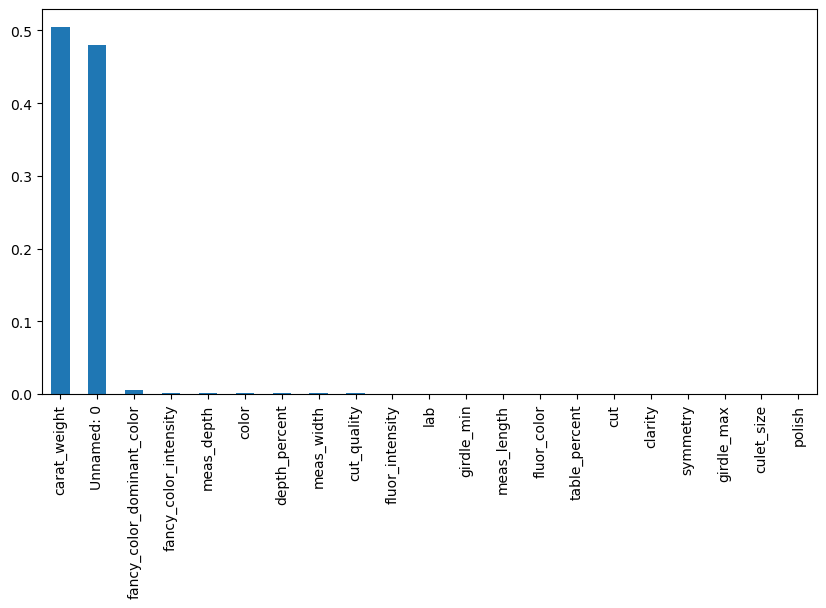

In [28]:
import pandas as pd

importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))